In [1]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

In [2]:
X, y= load_diabetes(return_X_y= True)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (442, 10)
y shape: (442,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=2)

In [4]:
sklearn_reg = LinearRegression()
sklearn_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_pred = sklearn_reg.predict(X_test)

print(f"SKlearn R2 score: {r2_score(y_true= y_test, y_pred= y_pred): .2f}%")

SKlearn R2 score:  0.44%


In [6]:
sklearn_reg.intercept_

151.88331005254167

In [7]:
sklearn_reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [8]:
class SGDRegressor:

    def __init__(self, learning_rate = 0.01, epochs = 50):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.loss_history = []

    
    def fit(self, X_train, y_train):

        #initialize weights
        self.intercept_ = np.random.randn()
        self.coef_ = np.random.randn(X_train.shape[1])
        n = X_train.shape[0]

        #prediction
        for i in range(self.epochs):
            #loop through all rows(one update per row)
            for j in range(n):

                # select random index:
                indx = np.random.randint(0, n)

                #make prediction for single row
                y_hat = np.dot(X_train[indx], self.coef_) + self.intercept_
                error = y_train[indx] - y_hat

                #calculate gradients(no mean because of 1 row)
                grad_intercept_ = -2 * (error)
                grad_coef_ = -2 * X_train[indx] * error

                #update weights
                self.intercept_ = self.intercept_ - self.learning_rate * grad_intercept_
                self.coef_ = self.coef_ - self.learning_rate * grad_coef_

            # compute loss on whole dataset
            y_pred = np.dot(X_train, self.coef_) + self.intercept_
            mse = np.mean((y_train - y_pred) ** 2)
        
            self.loss_history.append(mse)

    
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_



In [9]:
sgd = SGDRegressor()
sgd.fit(X_train, y_train)

In [10]:
y_pred = sgd.predict(X_test)

print(f"R2 score: {r2_score(y_true= y_test, y_pred= y_pred): .2f}%")

R2 score:  0.43%


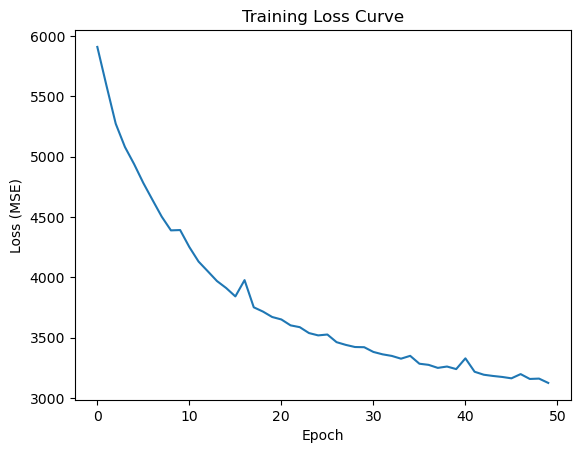

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(sgd.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss Curve")
plt.show()